In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install grad-cam

In [ ]:
import torch
import torchvision.models as models

def load_all_models(device):
    # Słownik na nasze modele
    models_dict = {}

    # 1. ResNet18
    #models_dict['resnet18'] = models.resnet18(weights='IMAGENET1K_V1').to(device)

    # 2. MobileNet V3 Large
    #models_dict['mobilenet_v3_large'] = models.mobilenet_v3_large(weights='IMAGENET1K_V1').to(device)

    # 3. EfficientNet B0
    #models_dict['efficientnet_b0'] = models.efficientnet_b0(weights='IMAGENET1K_V1').to(device)

    # 4. EfficientNet B3
    #models_dict['efficientnet_b3'] = models.efficientnet_b3(weights='IMAGENET1K_V1').to(device)

    # 5. SqueezeNet 1.1
    models_dict['squeezenet'] = models.squeezenet1_1(weights='IMAGENET1K_V1').to(device)

    # 6. ResNet50
    models_dict['resnet50'] = models.resnet50(weights='IMAGENET1K_V1').to(device)

    # 7. VGG16
    #models_dict['vgg16'] = models.vgg16(weights='IMAGENET1K_V1').to(device)

    # Przełączamy wszystkie modele w tryb ewaluacji (wyłączamy naukę)
    for name in models_dict:
        models_dict[name].eval()

    return models_dict

# Inicjalizacja
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
my_models = load_all_models(device)
print(f"Załadowano {len(my_models)} modeli  ")

Załadowano 2 modeli  


In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/XAI_Project/results/combined_predictions/all_models_combined_cat_predictions_without_nan.csv'
df_probabilities = pd.read_csv(file_path)

#print("Probabilities loaded into df_probabilities DataFrame. First 5 rows:")
#print(df_probabilities.head())

In [ ]:
index_of_cat_998 = df_probabilities[df_probabilities['filename'] == 'cat_998.jpg'].index[0]
filename = df_probabilities['filename'].iloc[index_of_cat_998]
print(f"The index of 'cat_998.jpg' is: {index_of_cat_998}")
print(f"Variable 'filename' has been set to: {filename}")

The index of 'cat_998.jpg' is: 597
Variable 'filename' has been set to: cat_998.jpg


In [ ]:
import warnings
warnings.filterwarnings('ignore')
from torchvision import models
import numpy as np
import cv2
from pytorch_grad_cam import GradCAM, HiResCAM, ScoreCAM, GradCAMPlusPlus, AblationCAM, XGradCAM, EigenCAM, FullGrad, RandomCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image, \
    deprocess_image, \
    preprocess_image
from PIL import Image
import time
import os
import torchvision.transforms as transforms # New import

# Define the base path for images
IMAGE_BASE_PATH = '/content/drive/MyDrive/XAI_Project/cats_images'

def find_image_path(base_path, filename):
    for root, _, files in os.walk(base_path):
        if filename in files:
            return os.path.join(root, filename)
    return None

filename = df_probabilities['filename'].iloc[597]
#filename = df_probabilities[df_probabilities['filename'] == 'cat_998.jpg']
print(f"Variable 'filename' has been created: {filename}")

# --- Configuration for CAM generation ---
selected_model_name = 'resnet50' # <--- Change this to select a different model from my_models
                               # e.g., 'mobilenet_v3_large', 'efficientnet_b0', 'squeezenet', 'vgg16'



# Use the 'filename' variable from context to find the image and data in df_probabilities
current_filename = filename # Use the 'filename' variable which is 'cat_10.jpg'

# Search for the image file recursively using the existing utility
# Assumes IMAGE_BASE_PATH and find_image_path are defined in previous cells
image_full_path = find_image_path(IMAGE_BASE_PATH, current_filename)

#if not image_full_path:
   # raise FileNotFoundError(f"Image file '{current_filename}' not found in '{IMAGE_BASE_PATH}' or its subdirectories.")

# --- New preprocessing pipeline ---
preprocess_pipeline = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Load the image using PIL
img_pil = Image.open(image_full_path).convert('RGB')


img = np.array(img_pil.resize((224, 224))) / 255.0

# Apply the new preprocessing pipeline to create the input tensor for the model
input_tensor = preprocess_pipeline(img_pil).unsqueeze(0) # Add batch dimension

# Determine the target class for CAM from df_probabilities for the current_filename
predicted_class_column = f'{selected_model_name}_top_1_class'
predicted_probability_column = f'{selected_model_name}_top_1_probability'

current_image_data = df_probabilities[df_probabilities['filename'] == current_filename].iloc[0].copy()

if predicted_class_column not in current_image_data:
    raise ValueError(f"Column '{predicted_class_column}' not found in df_probabilities for model '{selected_model_name}'.")

predicted_class_name = current_image_data[predicted_class_column]
predicted_probability = current_image_data[predicted_probability_column]

print(f"Processing image: {current_filename}")
print(f"Selected model: {selected_model_name}")
print(f"Predicted class from df_probabilities: {predicted_class_name}")

print(f"Predicted probability from df_probabilities: {predicted_probability:.4f}")

Variable 'filename' has been created: cat_998.jpg
Processing image: cat_998.jpg
Selected model: resnet50
Predicted class from df_probabilities: tabby
Predicted probability from df_probabilities: 0.5423


In [ ]:
import urllib.request

# Forcing re-download to ensure correctness for this run
print("Re-downloading ImageNet class mapping from pytorch/hub...")
url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
file_name = "imagenet_classes.txt"

try:
    urllib.request.urlretrieve(url, file_name)
    print(f"{file_name} downloaded successfully.")

    # Read the labels from the text file, one per line
    with open(file_name, 'r') as f:
        imagenet_labels = [line.strip() for line in f]

    label_to_idx = {label: i for i, label in enumerate(imagenet_labels)}
    print("ImageNet class index mapping re-loaded.")
except Exception as e:
    print(f"Error downloading or processing ImageNet labels: {e}")
    print("Please ensure you have an active internet connection.")

Re-downloading ImageNet class mapping from pytorch/hub...
imagenet_classes.txt downloaded successfully.
ImageNet class index mapping re-loaded.


In [ ]:
import numpy as np

# Randomly select 20 rows from the df_probabilities DataFrame
random_images_df = df_probabilities.sample(n=2, random_state=42)

# Extract the 'filename' column to get a list of selected filenames
selected_filenames = random_images_df['filename'].tolist()

#print(f"Selected {len(selected_filenames)} random filenames:")
#for filename in selected_filenames:
    #print(filename)

In [ ]:
import torch
import torch.nn.functional as F

model = my_models[selected_model_name]
# Perform a forward pass with the current model and input_tensor
with torch.no_grad():
    outputs = model(input_tensor)

# Apply softmax to get probabilities
probabilities = F.softmax(outputs, dim=1)

# Get the top-1 predicted class and its probability from the current model output
top_1_prob_current, top_1_idx_current = torch.max(probabilities, 1)

top_1_prob_current = top_1_prob_current.item()
top_1_idx_current = top_1_idx_current.item()

# Find the label name for the current top-1 index
current_top_1_label = None
for label, idx in label_to_idx.items():
    if idx == top_1_idx_current:
        current_top_1_label = label
        break

print(f"Current model's TOP-1 prediction for this image:")
print(f"  Class: {current_top_1_label} (Index: {top_1_idx_current})")
print(f"  Probability: {top_1_prob_current:.4f}")
print("\n--- Comparison --- ")
predicted_probability_column = f'{selected_model_name}_top_1_probability'
predicted_probability = df_probabilities[predicted_probability_column].iloc[1]
print(f"From df_probabilities: '{predicted_class_name}' with probability {predicted_probability:.4f}")
print(f"Manually retrieved for 'Egyptian cat' (index {top_1_idx_current}): {top_1_prob_current:.4f}")

Current model's TOP-1 prediction for this image:
  Class: tabby (Index: 281)
  Probability: 0.5423

--- Comparison --- 
From df_probabilities: 'tabby' with probability 0.9525
Manually retrieved for 'Egyptian cat' (index 281): 0.5423


In [ ]:
import torch
import torch.nn.functional as F
from PIL import Image
import numpy as np
import os
import torchvision.transforms as transforms

# Ensure the necessary variables are available from previous cells
# my_models, selected_model_name, df_probabilities, label_to_idx, IMAGE_BASE_PATH, find_image_path, device

# Get the selected model
model = my_models[selected_model_name]

# Define the preprocessing pipeline if not already defined
# (re-defining for clarity and to ensure it's available in this cell's context)
preprocess_pipeline = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

print(f"Processing {len(selected_filenames)} randomly selected images with model: {selected_model_name}\n")

for i, filename_to_process in enumerate(selected_filenames):
    print(f"--- Image {i+1}/{len(selected_filenames)}: {filename_to_process} ---")

    # 1. Find image path
    image_full_path = find_image_path(IMAGE_BASE_PATH, filename_to_process)
    if not image_full_path:
        print(f"  Error: Image '{filename_to_process}' not found. Skipping.\n")
        continue

    # 2. Preprocess the image
    img_pil = Image.open(image_full_path).convert('RGB')
    input_tensor = preprocess_pipeline(img_pil).unsqueeze(0).to(device)

    # 3. Retrieve predicted class and probability from df_probabilities
    current_image_data = df_probabilities[df_probabilities['filename'] == filename_to_process].iloc[0].copy()
    predicted_class_column = f'{selected_model_name}_top_1_class'
    predicted_probability_column = f'{selected_model_name}_top_1_probability'

    df_predicted_class_name = current_image_data[predicted_class_column]
    df_predicted_probability = current_image_data[predicted_probability_column]

    print(f"  From df_probabilities (model: {selected_model_name}):")
    print(f"    Class: {df_predicted_class_name}, Probability: {df_predicted_probability:.4f}")

    # 4. Perform a fresh top-1 prediction using the model
    with torch.no_grad():
        outputs = model(input_tensor)
    probabilities = F.softmax(outputs, dim=1)
    fresh_top_1_prob, fresh_top_1_idx = torch.max(probabilities, 1)

    fresh_top_1_prob = fresh_top_1_prob.item()
    fresh_top_1_idx = fresh_top_1_idx.item()

    fresh_top_1_label = None
    for label, idx in label_to_idx.items():
        if idx == fresh_top_1_idx:
            fresh_top_1_label = label
            break

    print(f"  Fresh TOP-1 prediction (model: {selected_model_name}):")
    print(f"    Class: {fresh_top_1_label} (Index: {fresh_top_1_idx}), Probability: {fresh_top_1_prob:.4f}")
    print("\n")

Processing 2 randomly selected images with model: resnet50

--- Image 1/2: cat_1597.jpg ---
  From df_probabilities (model: resnet50):
    Class: Siamese cat, Probability: 0.9988
  Fresh TOP-1 prediction (model: resnet50):
    Class: Siamese cat (Index: 284), Probability: 0.9988


--- Image 2/2: cat_2418.jpg ---
  From df_probabilities (model: resnet50):
    Class: Egyptian cat, Probability: 0.9837
  Fresh TOP-1 prediction (model: resnet50):
    Class: Egyptian cat (Index: 285), Probability: 0.9837




CAM calculation took: 3.2238 seconds


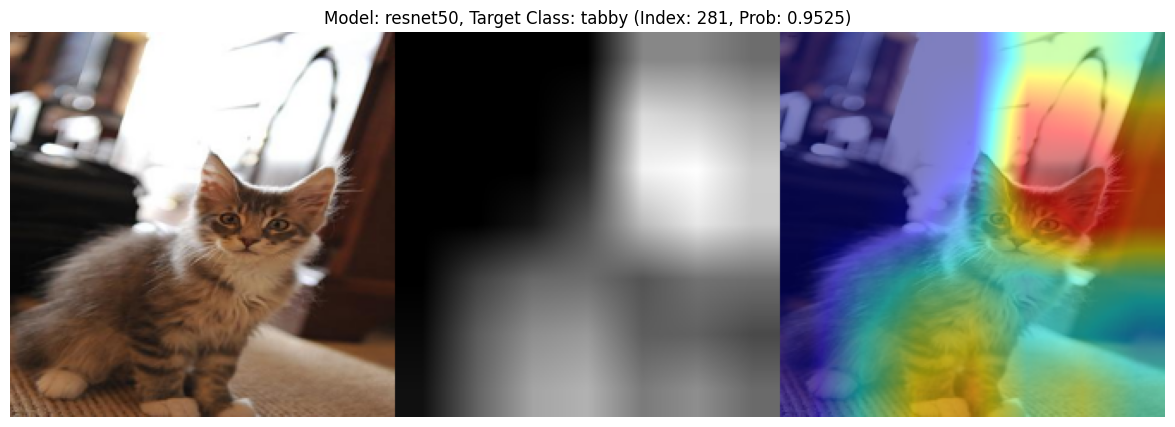

In [ ]:
import matplotlib.pyplot as plt

# Set target for GradCAM to the class predicted in df_probabilities
target_class_index_for_cam = label_to_idx[predicted_class_name]
targets = [ClassifierOutputTarget(target_class_index_for_cam)]

# Use the model from my_models dictionary
model_for_cam = my_models[selected_model_name]

# Recalculate GradCAM with the new target
start_time = time.time()
# Dynamically determine target layers based on the selected model
# This ensures that only attributes present in the 'model_for_cam' object are accessed.
# Also, being more specific about the final conv layer for some models.
if selected_model_name == 'resnet18':
    target_layers = [model_for_cam.layer4[-1].conv2] # More specific conv layer for ResNet18
elif selected_model_name == 'mobilenet_v3_large':
    target_layers = [model_for_cam.features[-1]]
elif selected_model_name == 'efficientnet_b0':
    target_layers = [model_for_cam.features[-1]]
elif selected_model_name == 'efficientnet_b3':
    target_layers = [model_for_cam.features[-1]]
elif selected_model_name == 'squeezenet':
    target_layers = [model_for_cam.features[-1]]
elif selected_model_name == 'resnet50':
    target_layers = [model_for_cam.layer4[-1].conv3] # More specific conv layer for ResNet50 (Bottleneck block)
elif selected_model_name == 'vgg16':
    target_layers = [model_for_cam.features] # VGG typically uses the entire features block, GradCAM will find the last conv layer
else:
    raise ValueError(f"Target layers for model '{selected_model_name}' are not defined.")

with GradCAM(model=model_for_cam, target_layers=target_layers) as cam:
     grayscale_cams = cam(input_tensor=input_tensor, targets=targets)
     cam_image = show_cam_on_image(img, grayscale_cams[0, :], use_rgb=True)
end_time = time.time()

print(f"CAM calculation took: {end_time - start_time:.4f} seconds")

cam = np.uint8(255*grayscale_cams[0, :])
cam = cv2.merge([cam, cam, cam])

# Create a figure to display the images with a title for 'Egyptian cat'
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
ax.imshow(np.hstack((np.uint8(255*img), cam, cam_image)))
ax.axis('off')
ax.set_title(f"Model: {selected_model_name}, Target Class: {predicted_class_name} (Index: {target_class_index_for_cam}, Prob: {predicted_probability:.4f})")
plt.show()

In [ ]:
# Ensure df_probabilities is loaded before running this cell
#if 'df_probabilities' in globals() and not df_probabilities.empty:
filename = df_probabilities['filename'].iloc[1]
print(f"Variable 'filename' has been created: {filename}")
#else:
   # print("Error: df_probabilities is not loaded or is empty. Cannot create 'filename' variable.")
 #   filename = None # Assign None if DataFrame is not available

Variable 'filename' has been created: cat_10.jpg


In [ ]:
import warnings
warnings.filterwarnings('ignore')
from torchvision import models
import numpy as np
import cv2
from pytorch_grad_cam import GradCAM, HiResCAM, ScoreCAM, GradCAMPlusPlus, AblationCAM, XGradCAM, EigenCAM, FullGrad, RandomCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image, \
    deprocess_image, \
    preprocess_image
from PIL import Image
import time
import os
import torchvision.transforms as transforms # New import

# --- Configuration for CAM generation ---
selected_model_name = 'squeezenet' # <--- Change this to select a different model from my_models
                               # e.g., 'mobilenet_v3_large', 'efficientnet_b0', 'squeezenet', 'vgg16'

# Get the model from the pre-loaded models dictionary
#if selected_model_name not in my_models:
 #   raise ValueError(f"Model '{selected_model_name}' not found in 'my_models'. Available models: {list(my_models.keys())}")
#model = my_models[selected_model_name]

# Use the 'filename' variable from context to find the image and data in df_probabilities
current_filename = filename # Use the 'filename' variable which is 'cat_10.jpg'

# Search for the image file recursively using the existing utility
# Assumes IMAGE_BASE_PATH and find_image_path are defined in previous cells
image_full_path = find_image_path(IMAGE_BASE_PATH, current_filename)

#if not image_full_path:
   # raise FileNotFoundError(f"Image file '{current_filename}' not found in '{IMAGE_BASE_PATH}' or its subdirectories.")

# --- New preprocessing pipeline ---
preprocess_pipeline = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Load the image using PIL
img_pil = Image.open(image_full_path).convert('RGB')

# Prepare 'img' for GradCAM visualization (numpy array 0-1, 224x224)
# It's derived from the PIL image and resized to 224x224.
img = np.array(img_pil.resize((224, 224))) / 255.0

# Apply the new preprocessing pipeline to create the input tensor for the model
input_tensor = preprocess_pipeline(img_pil).unsqueeze(0) # Add batch dimension


# Determine the target class for CAM from df_probabilities for the current_filename
predicted_class_column = f'{selected_model_name}_top_1_class'
predicted_probability_column = f'{selected_model_name}_top_1_probability'

# Find the row in df_probabilities that matches the current_filename
# Use .copy() to avoid SettingWithCopyWarning if df_probabilities is a slice
current_image_data = df_probabilities[df_probabilities['filename'] == current_filename].iloc[0].copy()

if predicted_class_column not in current_image_data:
    raise ValueError(f"Column '{predicted_class_column}' not found in df_probabilities for model '{selected_model_name}'.")

predicted_class_name = current_image_data[predicted_class_column]
predicted_probability = current_image_data[predicted_probability_column]

print(f"Processing image: {current_filename}")
print(f"Selected model: {selected_model_name}")
print(f"Predicted class from df_probabilities: {predicted_class_name}")

print(f"Predicted probability from df_probabilities: {predicted_probability:.4f}")

Processing image: cat_998.jpg
Selected model: squeezenet
Predicted class from df_probabilities: Egyptian cat
Predicted probability from df_probabilities: 0.5097


In [ ]:
import torch
from pytorch_grad_cam import GradCAM, HiResCAM, ScoreCAM, GradCAMPlusPlus, AblationCAM, XGradCAM, EigenCAM, FullGrad, RandomCAM

# 1. Select the resnet18 model from the my_models dictionary
model_for_cam_generation = my_models['squeezenet']
#target_layers = [model_for_cam_generation.features[-1]]
# 2. Define the target_layers for the resnet18 model
#target_layers = [model_for_cam_generation.layer4[-1].conv2]
# 2. Define the target_layers for the resnet50 model
#target_layers = [model_for_cam_generation.layer4[-1].conv3]
target_layers = [model_for_cam_generation.features[-1]],
#target_layers = [model_for_cam_generation['efficientnet_b3'].features[-1]],
#target_layers = [model_for_cam_generation.features[-1]]

# 3. Create a dictionary named cam_methods
cam_methods = {
    'GradCAM': GradCAM(model=model_for_cam_generation, target_layers=target_layers),
    'HiResCAM': HiResCAM(model=model_for_cam_generation, target_layers=target_layers),
    'GradCAMPlusPlus': GradCAMPlusPlus(model=model_for_cam_generation, target_layers=target_layers),
    'XGradCAM': XGradCAM(model=model_for_cam_generation, target_layers=target_layers),
    'EigenCAM': EigenCAM(model=model_for_cam_generation, target_layers=target_layers),
    'FullGrad': FullGrad(model=model_for_cam_generation, target_layers=target_layers),
    'RandomCAM': RandomCAM(model=model_for_cam_generation, target_layers=target_layers)
}

#print(f"Initialized {len(cam_methods)} CAM methods for {model_for_cam_generation}.")
#print(f"Target layers for {model_for_cam_generation}: {target_layers}")

AttributeError: 'list' object has no attribute 'register_forward_hook'

In [ ]:
import numpy as np
import cv2
import torch
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image, preprocess_image
from PIL import Image
import os
from tqdm import tqdm
import torchvision.transforms as transforms

# Ensure IMAGE_BASE_PATH, df_probabilities, device, and label_to_idx are available

# 1. Define output directory
# Corrected line: Use selected_model_name (string) instead of the model object
output_dir_multi_cam = os.path.join('/content/drive/MyDrive/XAI_Project/results_multi_cam/', selected_model_name)
os.makedirs(output_dir_multi_cam, exist_ok=True)

# 2. Preprocessing pipeline (re-using from previous cells)
preprocess_pipeline = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

print(f"Generating multi-CAM visualizations for images from df_probabilities...\nResults will be saved in: {output_dir_multi_cam}")

# Iterate through filenames from df_probabilities
for i, filename_from_df in enumerate(tqdm(df_probabilities['filename'], desc="Generating Multi-CAMs")):
    # Find the full path for the current filename
    image_full_path = find_image_path(IMAGE_BASE_PATH, filename_from_df)

    if not image_full_path:
        print(f"Error: Image '{filename_from_df}' not found in '{IMAGE_BASE_PATH}' or its subdirectories. Skipping.")
        continue

    try:
        # Wczytanie i przygotowanie obrazu
        img_pil = Image.open(image_full_path).convert('RGB')
        rgb_img_resized = np.array(img_pil.resize((224, 224))) # For visualization
        float_img = np.float32(rgb_img_resized) / 255

        # Create input tensor for the model
        input_tensor = preprocess_pipeline(img_pil).unsqueeze(0).to(device)

        # Determine the target class for CAM from df_probabilities for this specific file
        predicted_class_column = f'{selected_model_name}_top_1_class'

        # Fix 1: Correct pandas indexing for current_row_data
        current_row_data = df_probabilities[df_probabilities['filename'] == filename_from_df]
        if current_row_data.empty:
            print(f"Error: No data found for file '{filename_from_df}' in df_probabilities. Skipping.")
            continue

        predicted_class_name_from_df = current_row_data[predicted_class_column].iloc[0]

        # Fix 2: Use predicted_class_name_from_df for target_class_index
        target_class_index = label_to_idx[predicted_class_name_from_df]
        #print(f"Processing {filename_from_df}: Predicted class from df_probabilities: {predicted_class_name_from_df} (Index: {target_class_index})")

        targets = [ClassifierOutputTarget(target_class_index)]

        # Generate CAMs for each method
        for cam_name, cam_instance in cam_methods.items():
            try:
                # Generate grayscale CAM
                grayscale_cam = cam_instance(input_tensor=input_tensor, targets=targets)[0, :]

                # Create visualization (overlay map on original image)
                visualization = show_cam_on_image(float_img, grayscale_cam, use_rgb=True)

                # Create sub-directory for the CAM method if it doesn't exist
                method_output_dir = os.path.join(output_dir_multi_cam, cam_name)
                os.makedirs(method_output_dir, exist_ok=True)

                # Save visualization and raw data
                base_name = f"{os.path.splitext(filename_from_df)[0]}_{selected_model_name}_{predicted_class_name_from_df.replace(' ', '_')}"
                cv2.imwrite(os.path.join(method_output_dir, f"{base_name}_{cam_name}__vis.jpg"), cv2.cvtColor(visualization, cv2.COLOR_RGB2BGR))
                np.save(os.path.join(method_output_dir, f"{base_name}_{cam_name}_raw.npy"), grayscale_cam)

            except Exception as e:
                print(f"Error processing {cam_name} for '{filename_from_df}': {e}")

    except Exception as e:
        print(f"Error during initial processing of image '{filename_from_df}': {e}")

print(f"\nAll multi-CAM visualizations generated and saved in: {output_dir_multi_cam}")

Generating multi-CAM visualizations for images from df_probabilities...
Results will be saved in: /content/drive/MyDrive/XAI_Project/results_multi_cam/resnet50


Generating Multi-CAMs: 100%|██████████| 598/598 [1:34:06<00:00,  9.44s/it]


All multi-CAM visualizations generated and saved in: /content/drive/MyDrive/XAI_Project/results_multi_cam/resnet50


In [ ]:
import torch
from pytorch_grad_cam import GradCAM, HiResCAM, ScoreCAM, GradCAMPlusPlus, AblationCAM, XGradCAM, EigenCAM, FullGrad, RandomCAM

# 1. Select the resnet18 model from the my_models dictionary
model_for_cam_generation = my_models['squeezenet']
target_layers = [model_for_cam_generation.features[-1]]
# 2. Define the target_layers for the resnet18 model
#target_layers = [model_for_cam_generation.layer4[-1].conv2]
# 2. Define the target_layers for the resnet50 model
#target_layers = [model_for_cam_generation.layer4[-1].conv3]
#target_layers = [model_for_cam_generation['efficientnet_b0'].features[-1]],
#target_layers = [model_for_cam_generation['efficientnet_b3'].features[-1]],
#target_layers = [model_for_cam_generation.features[-1]]

# 3. Create a dictionary named cam_methods
cam_methods = {
    'GradCAM': GradCAM(model=model_for_cam_generation, target_layers=target_layers),
    'HiResCAM': HiResCAM(model=model_for_cam_generation, target_layers=target_layers),
    'GradCAMPlusPlus': GradCAMPlusPlus(model=model_for_cam_generation, target_layers=target_layers),
    'XGradCAM': XGradCAM(model=model_for_cam_generation, target_layers=target_layers),
    'EigenCAM': EigenCAM(model=model_for_cam_generation, target_layers=target_layers),
    'FullGrad': FullGrad(model=model_for_cam_generation, target_layers=target_layers),
    'RandomCAM': RandomCAM(model=model_for_cam_generation, target_layers=target_layers)
}

#print(f"Initialized {len(cam_methods)} CAM methods for {model_for_cam_generation}.")
#print(f"Target layers for {model_for_cam_generation}: {target_layers}")

In [ ]:
import numpy as np
import cv2
import torch
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image, preprocess_image
from PIL import Image
import os
from tqdm import tqdm
import torchvision.transforms as transforms

# Ensure IMAGE_BASE_PATH, df_probabilities, device, and label_to_idx are available

# 1. Define output directory
# Corrected line: Use selected_model_name (string) instead of the model object
output_dir_multi_cam = os.path.join('/content/drive/MyDrive/XAI_Project/results_multi_cam/squeezenet')
os.makedirs(output_dir_multi_cam, exist_ok=True)

# 2. Preprocessing pipeline (re-using from previous cells)
preprocess_pipeline = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

print(f"Generating multi-CAM visualizations for images from df_probabilities...\nResults will be saved in: {output_dir_multi_cam}")

# Iterate through filenames from df_probabilities
for i, filename_from_df in enumerate(tqdm(df_probabilities['filename'], desc="Generating Multi-CAMs")):
    # Find the full path for the current filename
    image_full_path = find_image_path(IMAGE_BASE_PATH, filename_from_df)

    if not image_full_path:
        print(f"Error: Image '{filename_from_df}' not found in '{IMAGE_BASE_PATH}' or its subdirectories. Skipping.")
        continue

    try:
        # Wczytanie i przygotowanie obrazu
        img_pil = Image.open(image_full_path).convert('RGB')
        rgb_img_resized = np.array(img_pil.resize((224, 224))) # For visualization
        float_img = np.float32(rgb_img_resized) / 255

        # Create input tensor for the model
        input_tensor = preprocess_pipeline(img_pil).unsqueeze(0).to(device)

        # Determine the target class for CAM from df_probabilities for this specific file
        predicted_class_column = f'{selected_model_name}_top_1_class'

        # Fix 1: Correct pandas indexing for current_row_data
        current_row_data = df_probabilities[df_probabilities['filename'] == filename_from_df]
        if current_row_data.empty:
            print(f"Error: No data found for file '{filename_from_df}' in df_probabilities. Skipping.")
            continue

        predicted_class_name_from_df = current_row_data[predicted_class_column].iloc[0]

        # Fix 2: Use predicted_class_name_from_df for target_class_index
        target_class_index = label_to_idx[predicted_class_name_from_df]
        #print(f"Processing {filename_from_df}: Predicted class from df_probabilities: {predicted_class_name_from_df} (Index: {target_class_index})")

        targets = [ClassifierOutputTarget(target_class_index)]

        # Generate CAMs for each method
        for cam_name, cam_instance in cam_methods.items():
            try:
                # Generate grayscale CAM
                grayscale_cam = cam_instance(input_tensor=input_tensor, targets=targets)[0, :]

                # Create visualization (overlay map on original image)
                visualization = show_cam_on_image(float_img, grayscale_cam, use_rgb=True)

                # Create sub-directory for the CAM method if it doesn't exist
                method_output_dir = os.path.join(output_dir_multi_cam, cam_name)
                os.makedirs(method_output_dir, exist_ok=True)

                # Save visualization and raw data
                base_name = f"{os.path.splitext(filename_from_df)[0]}_{selected_model_name}_{predicted_class_name_from_df.replace(' ', '_')}"
                cv2.imwrite(os.path.join(method_output_dir, f"{base_name}_{cam_name}__vis.jpg"), cv2.cvtColor(visualization, cv2.COLOR_RGB2BGR))
                np.save(os.path.join(method_output_dir, f"{base_name}_{cam_name}_raw.npy"), grayscale_cam)

            except Exception as e:
                print(f"Error processing {cam_name} for '{filename_from_df}': {e}")

    except Exception as e:
        print(f"Error during initial processing of image '{filename_from_df}': {e}")

print(f"\nAll multi-CAM visualizations generated and saved in: {output_dir_multi_cam}")

Generating multi-CAM visualizations for images from df_probabilities...
Results will be saved in: /content/drive/MyDrive/XAI_Project/results_multi_cam/squeezenet


Generating Multi-CAMs: 100%|██████████| 598/598 [22:47<00:00,  2.29s/it]


All multi-CAM visualizations generated and saved in: /content/drive/MyDrive/XAI_Project/results_multi_cam/squeezenet
